## 1. Import Libraries

In [5]:
# ==========================================
# CUSTOMER CHURN PREDICTION & SEGMENTATION
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 2.2.3
NumPy version: 2.1.3


In [8]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn sqlalchemy joblib

In [7]:
import sklearn
import joblib

print("Scikit-learn version:", sklearn.__version__)
print("All required libraries are ready!")

Scikit-learn version: 1.6.1
All required libraries are ready!


## 2. Load Dataset

In [9]:
import pandas as pd

df = pd.read_csv("/content/Telco-Customer-Churn.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Understanding


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 4. Data Cleaning

In [11]:
file_path = "/content/Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [12]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


In [14]:
df.shape

(7043, 21)

In [15]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [17]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [19]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [20]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


## 5. Exploratory Data Analysis

In [21]:
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [22]:
churn_counts = df["Churn"].value_counts()
print(churn_counts)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [23]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage.round(2))

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


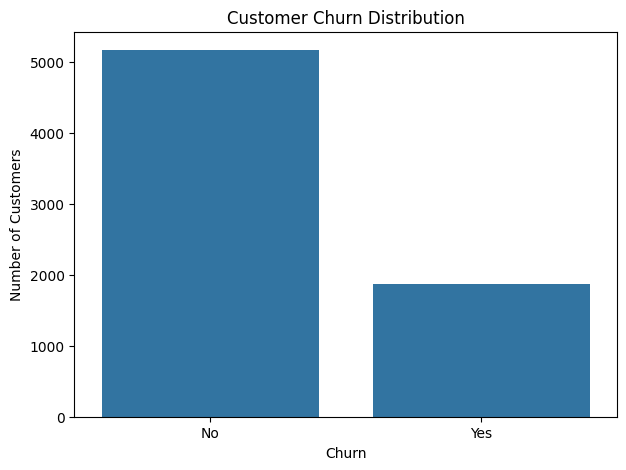

In [24]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

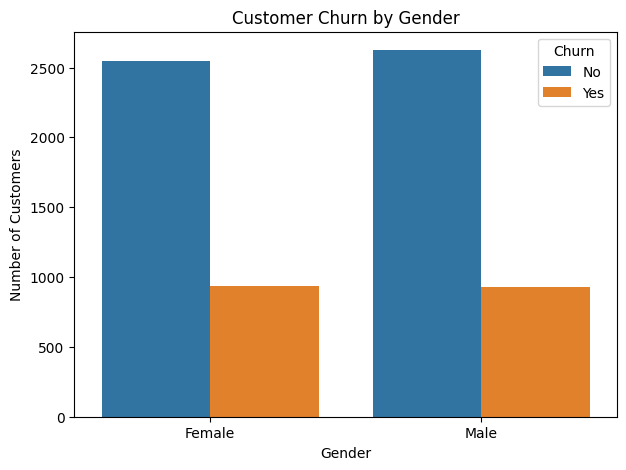

In [25]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

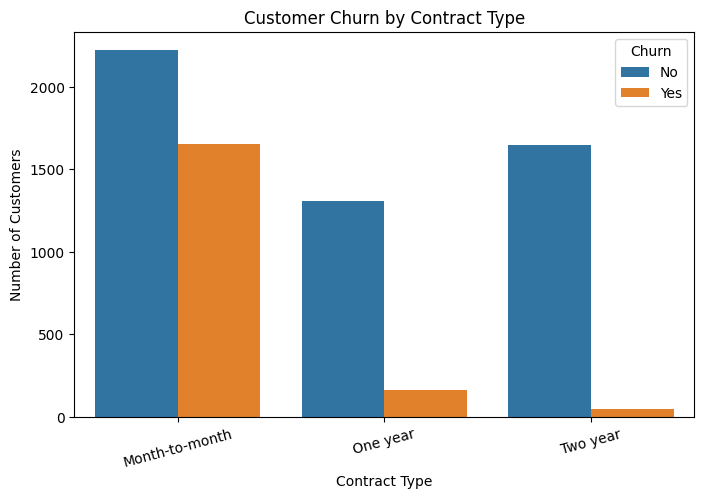

In [26]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

In [27]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [28]:
df["tenure"].describe()

,tenure
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


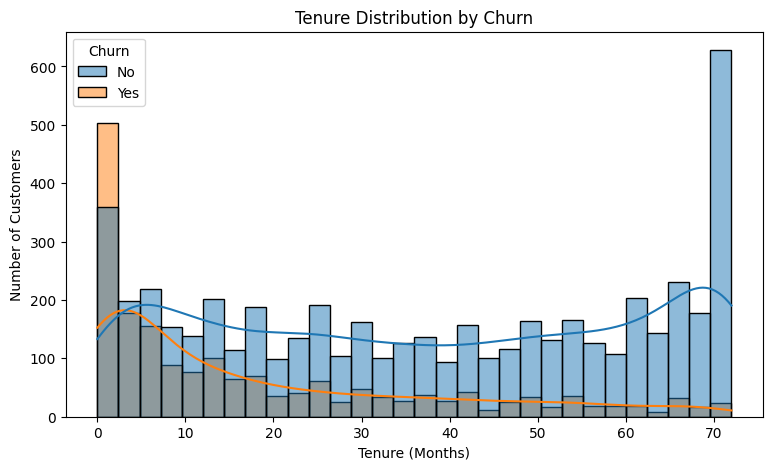

In [29]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    kde=True,
    bins=30
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [30]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

In [31]:
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn.round(2)

Churn,No,Yes
TenureGroup,,
0-12 Months,52.56,47.44
13-24 Months,71.29,28.71
25-48 Months,79.61,20.39
49-72 Months,90.49,9.51


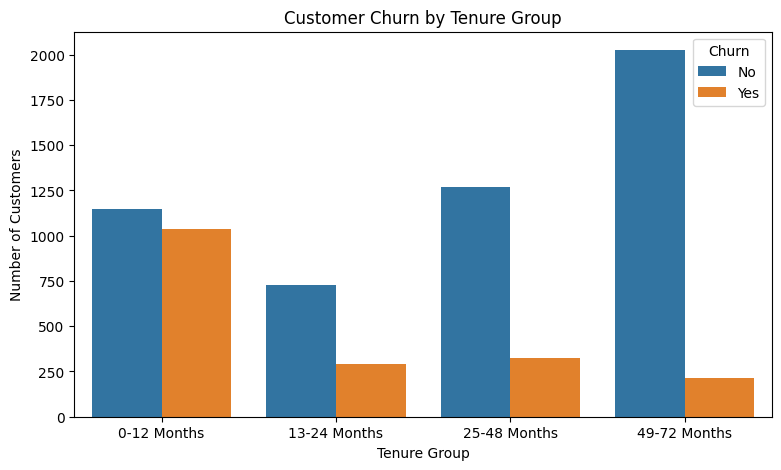

In [32]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="TenureGroup",
    hue="Churn"
)

plt.title("Customer Churn by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")

plt.show()

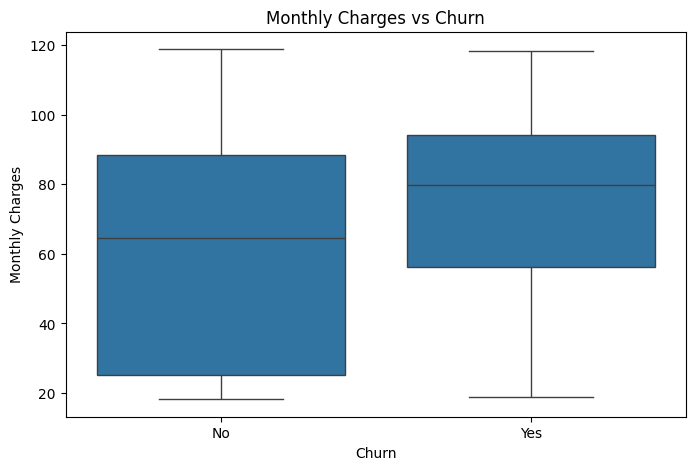

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [34]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


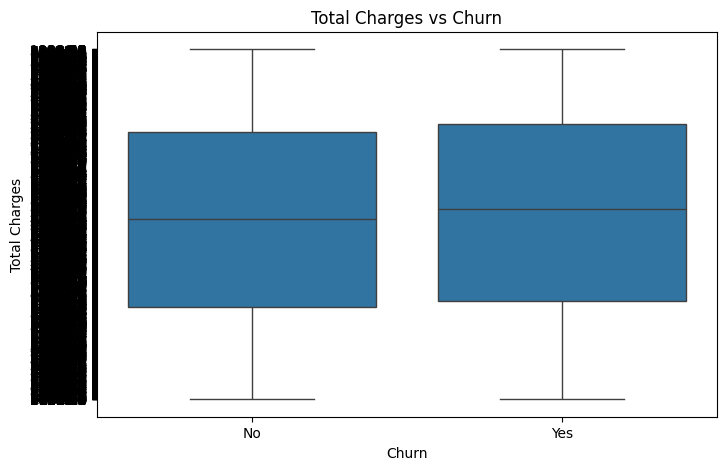

In [35]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

In [41]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.groupby("Churn")["TotalCharges"].mean()

,TotalCharges
Churn,
No,2555.344141
Yes,1531.796094


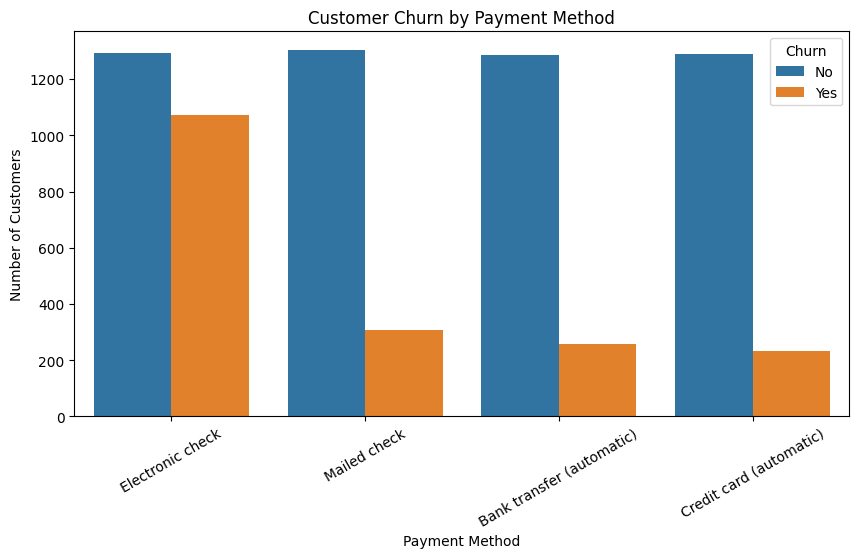

In [42]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

In [43]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn.round(2)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


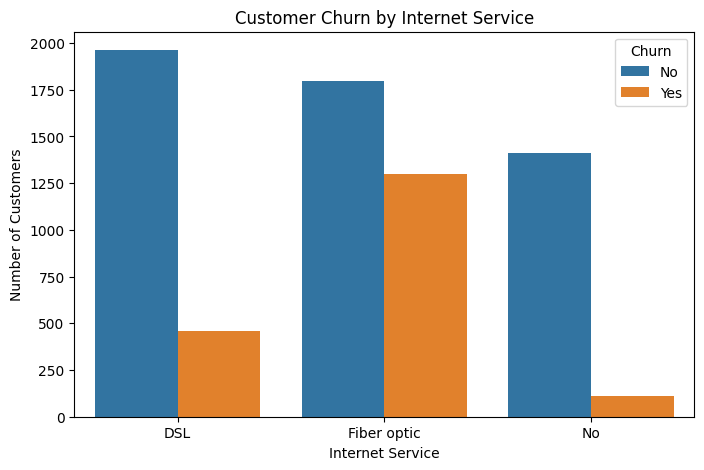

In [44]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [45]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


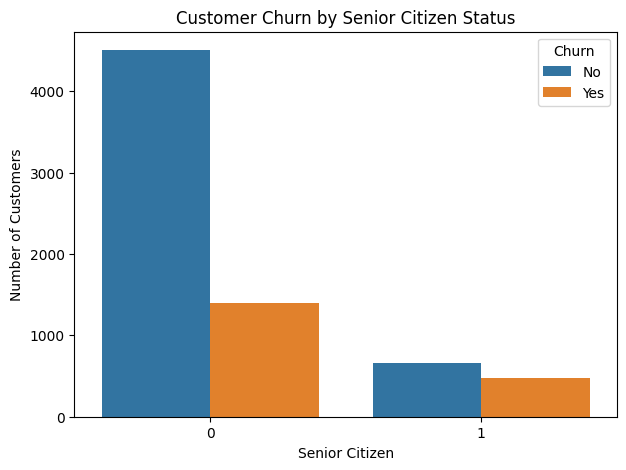

In [46]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.show()

In [47]:
def plot_churn_by_column(data, column):

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=data,
        x=column,
        hue="Churn"
    )

    plt.title(f"Customer Churn by {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")

    plt.xticks(rotation=20)

    plt.show()

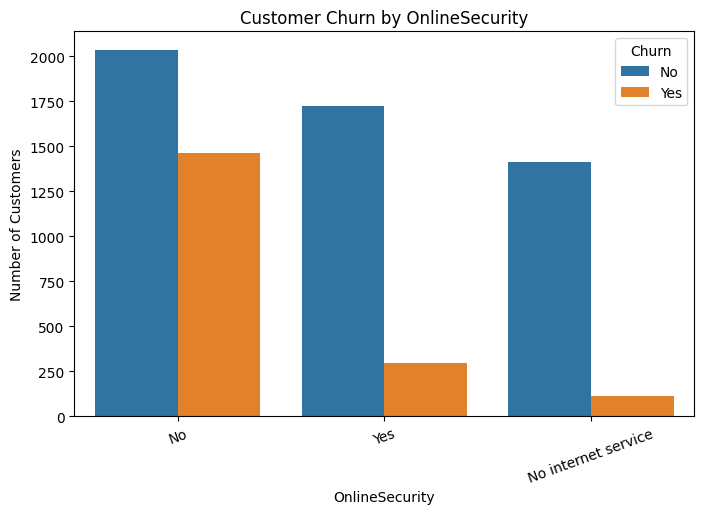

In [48]:
plot_churn_by_column(df, "OnlineSecurity")

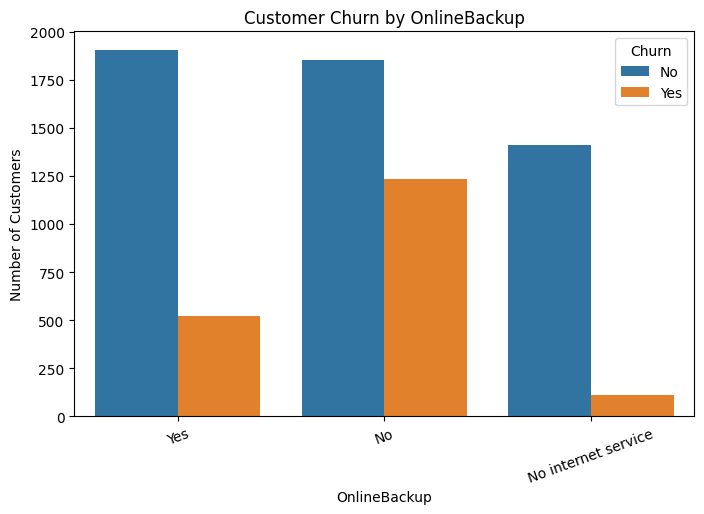

In [49]:
plot_churn_by_column(df, "OnlineBackup")

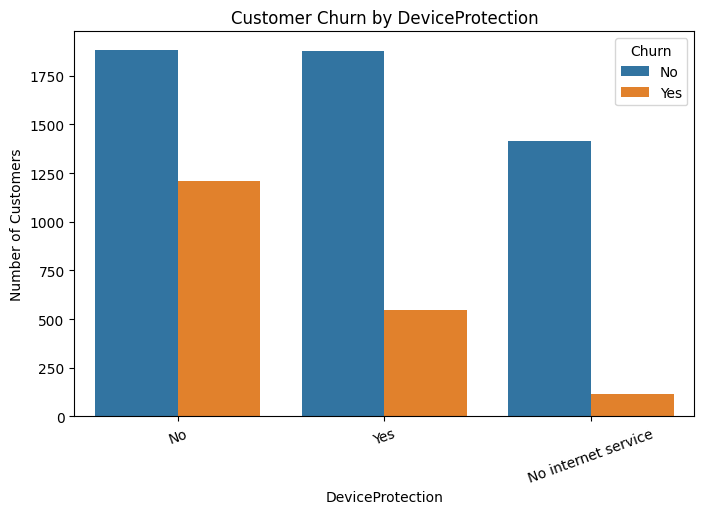

In [50]:
plot_churn_by_column(df, "DeviceProtection")

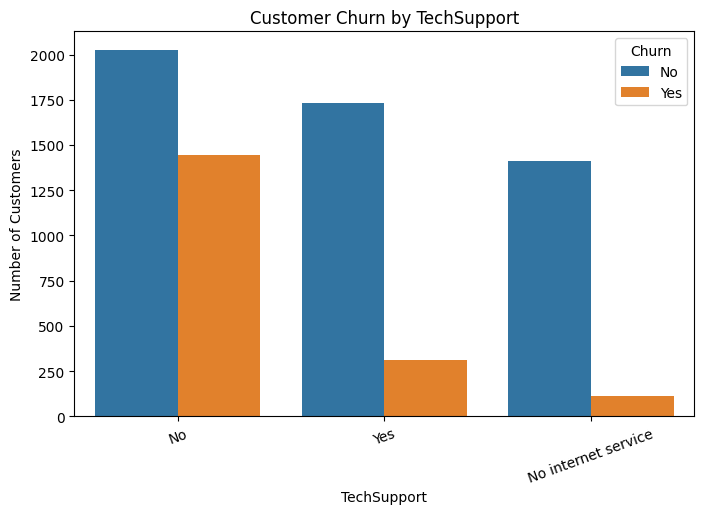

In [51]:
plot_churn_by_column(df, "TechSupport")

In [52]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


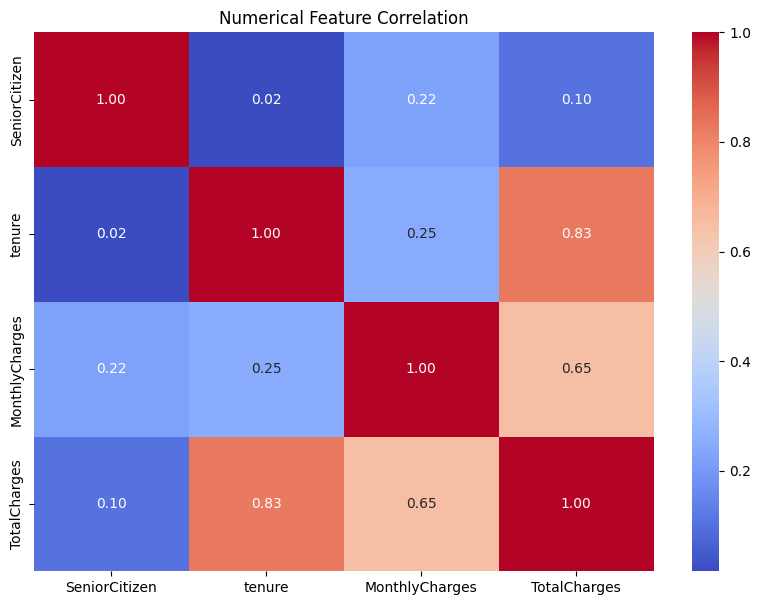

In [53]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Numerical Feature Correlation")

plt.show()

In [54]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Active Customers",
        "Overall Churn Rate",
        "Average Tenure",
        "Average Monthly Charges"
    ],
    "Value": [
        len(df),
        (df["Churn"] == "Yes").sum(),
        (df["Churn"] == "No").sum(),
        round((df["Churn"] == "Yes").mean() * 100, 2),
        round(df["tenure"].mean(), 2),
        round(df["MonthlyCharges"].mean(), 2)
    ]
})

eda_summary

,Metric,Value
0,Total Customers,7043.00
1,Churned Customers,1869.00
2,Active Customers,5174.00
3,Overall Churn Rate,26.54
4,Average Tenure,32.37
5,Average Monthly Charges,64.76


In [55]:
contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [56]:
tenure_churn.round(2)

Churn,No,Yes
TenureGroup,,
0-12 Months,52.56,47.44
13-24 Months,71.29,28.71
25-48 Months,79.61,20.39
49-72 Months,90.49,9.51


In [57]:
payment_churn.round(2)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


In [58]:
internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


## 6. Feature Engineering

In [59]:
customer_ids = df["customerID"].copy()

In [60]:
customer_ids.head()

,customerID
0,7590-VHVEG
1,5575-GNVDE
2,3668-QPYBK
3,7795-CFOCW
4,9237-HQITU


In [61]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "New",
        "Growing",
        "Established",
        "Loyal"
    ]
)

In [62]:
df[["tenure", "TenureGroup"]].head(10)

,tenure,TenureGroup
0,1,New
1,34,Established
2,2,New
3,45,Established
4,2,New
5,8,New
6,22,Growing
7,10,New
8,28,Established
9,62,Loyal


In [63]:
service_columns = [
    "PhoneService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [64]:
df["TotalServices"] = (
    df[service_columns]
    .apply(lambda col: col.eq("Yes").astype(int))
    .sum(axis=1)
)

In [65]:
df[["TotalServices"]].head(10)


,TotalServices
0,1
1,3
2,3
3,3
4,1
5,4
6,3
7,1
8,5
9,3


In [66]:
df["TotalServices"].value_counts().sort_index()

,count
TotalServices,
0,80
1,2253
2,996
3,1041
4,1062
5,827
6,525
7,259


In [67]:
df["AverageMonthlySpend"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

In [68]:
df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "AverageMonthlySpend"
    ]
].head(10)

,tenure,MonthlyCharges,TotalCharges,AverageMonthlySpend
0,1,29.85,29.85,29.850000
1,34,56.95,1889.50,55.573529
2,2,53.85,108.15,54.075000
3,45,42.30,1840.75,40.905556
4,2,70.70,151.65,75.825000
5,8,99.65,820.50,102.562500
6,22,89.10,1949.40,88.609091
7,10,29.75,301.90,30.190000
8,28,104.80,3046.05,108.787500
9,62,56.15,3487.95,56.257258


In [69]:
df["IsNewCustomer"] = np.where(
    df["tenure"] <= 12,
    1,
    0
)

In [70]:
df[
    ["tenure", "IsNewCustomer"]
].head(10)

,tenure,IsNewCustomer
0,1,1
1,34,0
2,2,1
3,45,0
4,2,1
5,8,1
6,22,0
7,10,1
8,28,0
9,62,0


In [71]:
high_charge_threshold = df["MonthlyCharges"].quantile(0.75)

print(
    "High monthly charge threshold:",
    round(high_charge_threshold, 2)
)

High monthly charge threshold: 89.85


In [72]:
df["HighMonthlyCharge"] = np.where(
    df["MonthlyCharges"] >= high_charge_threshold,
    1,
    0
)

In [73]:
df[
    ["MonthlyCharges", "HighMonthlyCharge"]
].head(10)

,MonthlyCharges,HighMonthlyCharge
0,29.85,0
1,56.95,0
2,53.85,0
3,42.30,0
4,70.70,0
5,99.65,1
6,89.10,0
7,29.75,0
8,104.80,1
9,56.15,0


In [74]:
new_features = [
    "TenureGroup",
    "TotalServices",
    "AverageMonthlySpend",
    "IsNewCustomer",
    "HighMonthlyCharge"
]

df[new_features].head(10)

,TenureGroup,TotalServices,AverageMonthlySpend,IsNewCustomer,HighMonthlyCharge
0,New,1,29.850000,1,0
1,Established,3,55.573529,0,0
2,New,3,54.075000,1,0
3,Established,3,40.905556,0,0
4,New,1,75.825000,1,0
5,New,4,102.562500,1,1
6,Growing,3,88.609091,0,0
7,New,1,30.190000,1,0
8,Established,5,108.787500,0,1
9,Loyal,3,56.257258,0,0


In [75]:
service_churn = pd.crosstab(
    df["TotalServices"],
    df["Churn"],
    normalize="index"
) * 100

service_churn.round(2)

Churn,No,Yes
TotalServices,,
0,56.25,43.75
1,78.34,21.66
2,56.53,43.47
3,65.32,34.68
4,72.79,27.21
5,77.99,22.01
6,87.43,12.57
7,94.21,5.79


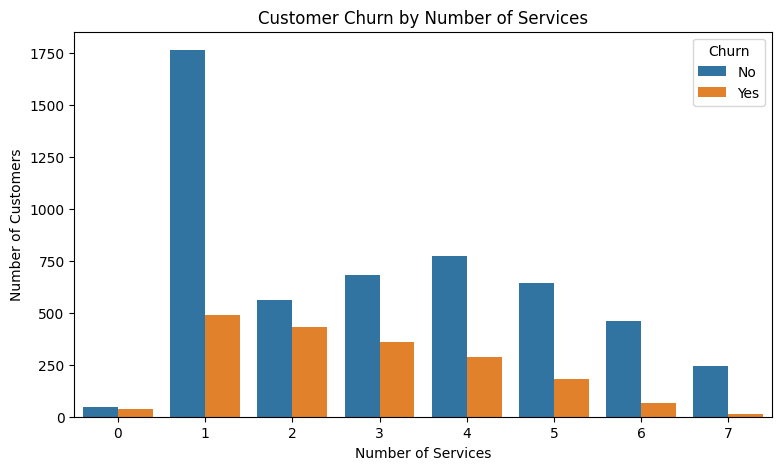

In [76]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="TotalServices",
    hue="Churn"
)

plt.title("Customer Churn by Number of Services")
plt.xlabel("Number of Services")
plt.ylabel("Number of Customers")

plt.show()

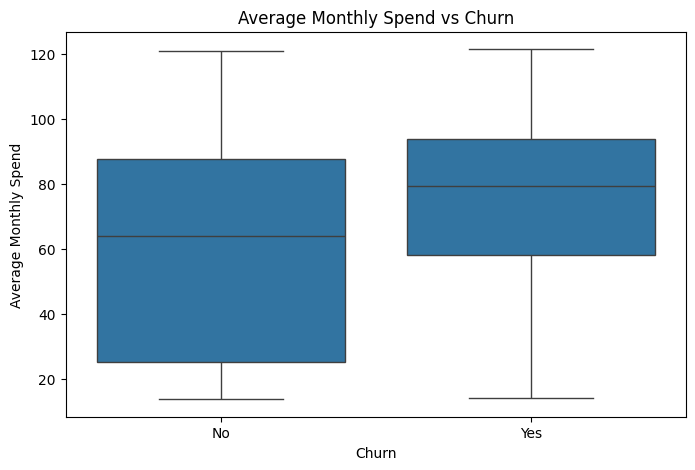

In [77]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="AverageMonthlySpend"
)

plt.title("Average Monthly Spend vs Churn")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Spend")

plt.show()

In [78]:
new_customer_churn = pd.crosstab(
    df["IsNewCustomer"],
    df["Churn"],
    normalize="index"
) * 100

new_customer_churn.round(2)

Churn,No,Yes
IsNewCustomer,,
0,82.87,17.13
1,52.56,47.44


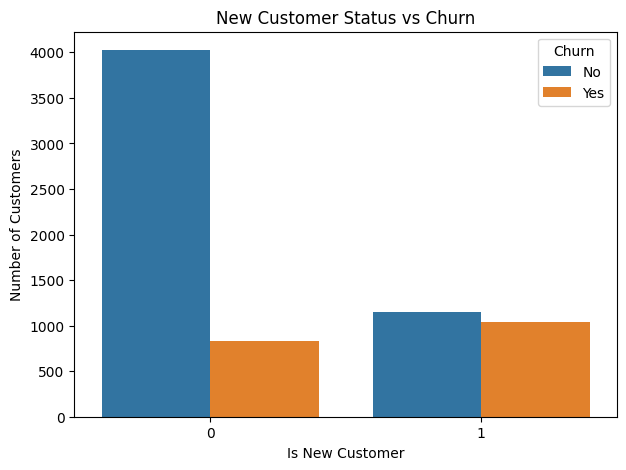

In [79]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="IsNewCustomer",
    hue="Churn"
)

plt.title("New Customer Status vs Churn")
plt.xlabel("Is New Customer")
plt.ylabel("Number of Customers")

plt.show()

In [80]:
print("Shape:", df.shape)

Shape: (7043, 26)


In [81]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
customerID              0
gender                  0
SeniorCitizen           0
Partner                 0
Dependents              0
tenure                  0
PhoneService            0
MultipleLines           0
InternetService         0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
StreamingTV             0
StreamingMovies         0
Contract                0
PaperlessBilling        0
PaymentMethod           0
MonthlyCharges          0
TotalCharges           11
Churn                   0
TenureGroup             0
TotalServices           0
AverageMonthlySpend     0
IsNewCustomer           0
HighMonthlyCharge       0
dtype: int64


In [82]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [83]:
customer_ids = df["customerID"].copy()

In [84]:
df_ml = df.drop("customerID", axis=1)

In [85]:
print("ML dataset shape:", df_ml.shape)

ML dataset shape: (7043, 25)


In [86]:
df_ml["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


## 7. SQL Analysis

In [87]:
import sqlite3

In [88]:
conn = sqlite3.connect("customer_churn.db")
print("SQLite database created successfully!")

SQLite database created successfully!


In [89]:
import pandas as pd

file_path = "/content/Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

sql_df = df.copy()

sql_df["Churn"] = sql_df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [90]:
sql_df[["Churn"]].head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [91]:
sql_df.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

print("Customer data loaded into SQL table!")

Customer data loaded into SQL table!


In [92]:
query = """
SELECT *
FROM customers
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [93]:
query = """
SELECT COUNT(*) AS total_customers
FROM customers;
"""

pd.read_sql_query(query, conn)

,total_customers
0,7043


In [94]:
query = """
SELECT
    SUM(Churn) AS churned_customers
FROM customers;
"""

pd.read_sql_query(query, conn)

,churned_customers
0,1869


In [95]:
query = """
SELECT
    COUNT(*) AS total_customers,
    SUM(Churn) AS churned_customers,
    ROUND(
        100.0 * SUM(Churn) / COUNT(*),
        2
    ) AS churn_rate
FROM customers;
"""

pd.read_sql_query(query, conn)

,total_customers,churned_customers,churn_rate
0,7043,1869,26.54


In [96]:
query = """
SELECT
    Contract,
    COUNT(*) AS total_customers,
    SUM(Churn) AS churned_customers,
    ROUND(
        100.0 * SUM(Churn) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Contract
ORDER BY churn_rate DESC;
"""

contract_sql = pd.read_sql_query(query, conn)

contract_sql

,Contract,total_customers,churned_customers,churn_rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


In [97]:
query = """
SELECT
    PaymentMethod,
    COUNT(*) AS total_customers,
    SUM(Churn) AS churned_customers,
    ROUND(
        100.0 * SUM(Churn) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY PaymentMethod
ORDER BY churn_rate DESC;
"""

payment_sql = pd.read_sql_query(query, conn)

payment_sql

,PaymentMethod,total_customers,churned_customers,churn_rate
0,Electronic check,2365,1071,45.29
1,Mailed check,1612,308,19.11
2,Bank transfer (automatic),1544,258,16.71
3,Credit card (automatic),1522,232,15.24


In [98]:
query = """
SELECT
    InternetService,
    COUNT(*) AS total_customers,
    SUM(Churn) AS churned_customers,
    ROUND(
        100.0 * SUM(Churn) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY InternetService
ORDER BY churn_rate DESC;
"""

internet_sql = pd.read_sql_query(query, conn)

internet_sql

,InternetService,total_customers,churned_customers,churn_rate
0,Fiber optic,3096,1297,41.89
1,DSL,2421,459,18.96
2,No,1526,113,7.40


In [99]:
import pandas as pd

# The TenureGroup column needs to be added to the SQL table
# First, ensure TenureGroup is in sql_df based on the tenure column
sql_df['TenureGroup'] = pd.cut(
    sql_df['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-12 Months', '13-24 Months', '25-48 Months', '49-72 Months']
)

# Update the SQL table
sql_df.to_sql('customers', conn, if_exists='replace', index=False)

# Now the query will work
query = """
SELECT
    TenureGroup,
    COUNT(*) AS total_customers,
    SUM(Churn) AS churned_customers,
    ROUND(
        100.0 * SUM(Churn) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY TenureGroup
ORDER BY churn_rate DESC;
"""

tenure_sql = pd.read_sql_query(query, conn)
tenure_sql

,TenureGroup,total_customers,churned_customers,churn_rate
0,0-12 Months,2186,1037,47.44
1,13-24 Months,1024,294,28.71
2,25-48 Months,1594,325,20.39
3,49-72 Months,2239,213,9.51


In [100]:
query = """
SELECT
    Churn,
    COUNT(*) AS customers,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges
FROM customers
GROUP BY Churn;
"""

pd.read_sql_query(query, conn)

,Churn,customers,avg_monthly_charges
0,0,5174,61.27
1,1,1869,74.44


In [101]:
query = """
SELECT
    Churn,
    COUNT(*) AS customers,
    ROUND(AVG(tenure), 2) AS avg_tenure
FROM customers
GROUP BY Churn;
"""

pd.read_sql_query(query, conn)

,Churn,customers,avg_tenure
0,0,5174,37.57
1,1,1869,17.98


In [102]:
sql_df['TotalCharges'] = pd.to_numeric(sql_df['TotalCharges'], errors='coerce')
high_value_threshold = sql_df["TotalCharges"].quantile(0.75)

query = f"""
SELECT
    customerID,
    tenure,
    MonthlyCharges,
    TotalCharges,
    Contract,
    Churn
FROM customers
WHERE TotalCharges >= {high_value_threshold}
AND Churn = 1
ORDER BY TotalCharges DESC;
"""

high_value_churned = pd.read_sql_query(query, conn)

high_value_churned.head(20)

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
0,5899-MQZZL,13,75.00,999.45,Month-to-month,1
1,6328-ZPBGN,11,95.15,997.65,Month-to-month,1
2,6227-HWPWX,15,69.00,994.8,Month-to-month,1
3,7459-RRWQZ,15,64.65,994.55,Month-to-month,1
4,8443-WVPSS,10,99.85,990.9,Month-to-month,1
5,4695-VADHF,18,57.45,990.85,Month-to-month,1
6,0107-YHINA,1,99.75,99.75,Month-to-month,1
7,7384-GHBPI,3,35.15,99.75,Month-to-month,1
8,2157-MXBJS,13,75.30,989.45,One year,1
9,7321-PKUYW,11,90.15,987.95,Month-to-month,1


In [103]:
query = """
SELECT
    Contract,
    COUNT(*) AS Customers,
    SUM(Churn) AS ChurnedCustomers,
    ROUND(
        100.0 * SUM(Churn) / COUNT(*),
        2
    ) AS ChurnRate,
    ROUND(AVG(MonthlyCharges), 2) AS AvgMonthlyCharges,
    ROUND(AVG(tenure), 2) AS AvgTenure
FROM customers
GROUP BY Contract
ORDER BY ChurnRate DESC;
"""

sql_business_summary = pd.read_sql_query(query, conn)

sql_business_summary

,Contract,Customers,ChurnedCustomers,ChurnRate,AvgMonthlyCharges,AvgTenure
0,Month-to-month,3875,1655,42.71,66.40,18.04
1,One year,1473,166,11.27,65.05,42.04
2,Two year,1695,48,2.83,60.77,56.74


In [ ]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """,
    conn
)

tables

,name
0,customers


## 8. Machine Learning Preprocessing

In [104]:
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

print("Machine Learning libraries imported successfully!")

Machine Learning libraries imported successfully!


In [105]:
df_ml = df.drop("customerID", axis=1)
print("ML Dataset Shape:", df_ml.shape)
df_ml.head()

ML Dataset Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [106]:
X = df_ml.drop("Churn", axis=1)
y = df_ml["Churn"]

In [107]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


In [108]:
y = y.map({
    "No": 0,
    "Yes": 1
})

In [109]:
y.value_counts()

,count
Churn,
0,5174
1,1869


In [110]:
print(y.unique())

[0 1]


In [111]:
X.isnull().sum().sort_values(ascending=False).head(20)

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [113]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5634, 19)
Testing features: (1409, 19)
Training target: (5634,)
Testing target: (1409,)


In [114]:
stratify=y

In [115]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numeric_features

['SeniorCitizen', 'tenure', 'MonthlyCharges']

In [116]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges']

In [117]:
print("Number of numerical features:",
      len(numeric_features))

print("Number of categorical features:",
      len(categorical_features))

print("\nNumerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Number of numerical features: 3
Number of categorical features: 16

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']


In [118]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [119]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [120]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [121]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [122]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [123]:
print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)

Processed training shape: (5634, 5320)
Processed testing shape: (1409, 5320)


In [124]:
preprocessor.fit_transform(X_train)

array([[-0.44177295,  0.10237124, -0.52197565, ...,  0.        ,
         0.        ,  0.        ],
       [-0.44177295, -0.71174346,  0.33747781, ...,  0.        ,
         0.        ,  0.        ],
       [-0.44177295, -0.79315493, -0.80901319, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 2.2636062 , -0.30468611,  1.25666162, ...,  0.        ,
         0.        ,  0.        ],
       [-0.44177295, -0.34539184, -1.47766135, ...,  0.        ,
         0.        ,  0.        ],
       [-0.44177295, -1.07809507, -1.46936546, ...,  0.        ,
         0.        ,  0.        ]])

In [125]:
preprocessor.transform(X_test)

array([[-0.44177295,  1.60848343,  1.62997635, ...,  0.        ,
         0.        ,  0.        ],
       [ 2.2636062 , -0.9966836 ,  1.16872526, ...,  0.        ,
         0.        ,  0.        ],
       [-0.44177295,  0.34660565,  0.44532428, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.44177295, -1.11880081, -1.46936546, ...,  0.        ,
         0.        ,  0.        ],
       [-0.44177295,  0.95719167, -1.50088982, ...,  0.        ,
         0.        ,  0.        ],
       [-0.44177295,  1.60848343,  0.18317439, ...,  0.        ,
         0.        ,  0.        ]])

In [126]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training target distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


In [127]:
customer_ids = df["customerID"].copy()
customer_ids

,customerID
0,7590-VHVEG
1,5575-GNVDE
2,3668-QPYBK
3,7795-CFOCW
4,9237-HQITU
...,...
7038,6840-RESVB
7039,2234-XADUH
7040,4801-JZAZL
7041,8361-LTMKD


In [128]:
print("Customer IDs:", len(customer_ids))
customer_ids.head()

Customer IDs: 7043


,customerID
0,7590-VHVEG
1,5575-GNVDE
2,3668-QPYBK
3,7795-CFOCW
4,9237-HQITU


## Train the Machine Learning Models

In [129]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

print("ML models imported successfully!")

ML models imported successfully!


In [130]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Evaluation metrics imported successfully!")

Evaluation metrics imported successfully!


## 9. Logistic Regression

In [131]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [132]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TotalCharges'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [133]:
y_pred_logistic = logistic_model.predict(X_test)

y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

In [134]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic
)

logistic_roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

In [135]:
print("Logistic Regression Results")
print("--------------------------------")

print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))
print("ROC-AUC  :", round(logistic_roc_auc, 4))

Logistic Regression Results
--------------------------------
Accuracy : 0.7942
Precision: 0.6312
Recall   : 0.5401
F1 Score : 0.5821
ROC-AUC  : 0.8403


In [136]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



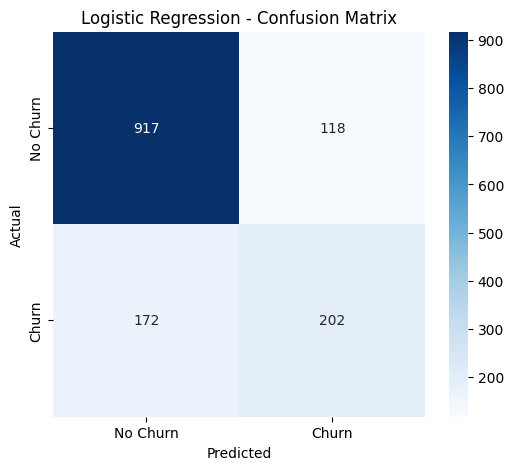

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 10. Decision Tree

In [138]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=6,
                random_state=42
            )
        )
    ]
)

In [139]:
decision_tree_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TotalCharges'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=6, random_state=42))])

In [140]:
y_pred_tree = decision_tree_model.predict(X_test)

y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

In [141]:
tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

tree_precision = precision_score(
    y_test,
    y_pred_tree
)

tree_recall = recall_score(
    y_test,
    y_pred_tree
)

tree_f1 = f1_score(
    y_test,
    y_pred_tree
)

tree_roc_auc = roc_auc_score(
    y_test,
    y_prob_tree
)

In [142]:
print("Decision Tree Results")
print("--------------------------------")

print("Accuracy :", round(tree_accuracy, 4))
print("Precision:", round(tree_precision, 4))
print("Recall   :", round(tree_recall, 4))
print("F1 Score :", round(tree_f1, 4))
print("ROC-AUC  :", round(tree_roc_auc, 4))

Decision Tree Results
--------------------------------
Accuracy : 0.7963
Precision: 0.6582
Recall   : 0.484
F1 Score : 0.5578
ROC-AUC  : 0.8364


## 11. Random Forest

In [143]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                min_samples_split=5,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [144]:
random_forest_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_...
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TotalCharges'])])),
                ('model',
                 RandomForestClassifier(max_depth=10, min_samples_split=5,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [145]:
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [146]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

In [147]:
print("Random Forest Results")
print("--------------------------------")

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

Random Forest Results
--------------------------------
Accuracy : 0.7395
Precision: 0.8182
Recall   : 0.0241
F1 Score : 0.0468
ROC-AUC  : 0.8167


## 12. Gradient Boosting

In [148]:
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=150,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

In [149]:
gradient_boosting_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TotalCharges'])])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=150,
                                            random_state=42))])

In [150]:
y_pred_gb = gradient_boosting_model.predict(X_test)

y_prob_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]

In [151]:
gb_accuracy = accuracy_score(
    y_test,
    y_pred_gb
)

gb_precision = precision_score(
    y_test,
    y_pred_gb
)

gb_recall = recall_score(
    y_test,
    y_pred_gb
)

gb_f1 = f1_score(
    y_test,
    y_pred_gb
)

gb_roc_auc = roc_auc_score(
    y_test,
    y_prob_gb
)

In [152]:
print("Gradient Boosting Results")
print("--------------------------------")

print("Accuracy :", round(gb_accuracy, 4))
print("Precision:", round(gb_precision, 4))
print("Recall   :", round(gb_recall, 4))
print("F1 Score :", round(gb_f1, 4))
print("ROC-AUC  :", round(gb_roc_auc, 4))

Gradient Boosting Results
--------------------------------
Accuracy : 0.8048
Precision: 0.6774
Recall   : 0.5053
F1 Score : 0.5789
ROC-AUC  : 0.8459


## 13. Model Comparison

In [153]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy,
        gb_accuracy
    ],

    "Precision": [
        logistic_precision,
        tree_precision,
        rf_precision,
        gb_precision
    ],

    "Recall": [
        logistic_recall,
        tree_recall,
        rf_recall,
        gb_recall
    ],

    "F1 Score": [
        logistic_f1,
        tree_f1,
        rf_f1,
        gb_f1
    ],

    "ROC-AUC": [
        logistic_roc_auc,
        tree_roc_auc,
        rf_roc_auc,
        gb_roc_auc
    ]
})

In [154]:
results = results.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.8048,0.6774,0.5053,0.5789,0.8459
1,Logistic Regression,0.7942,0.6312,0.5401,0.5821,0.8403
2,Decision Tree,0.7963,0.6582,0.4840,0.5578,0.8364
3,Random Forest,0.7395,0.8182,0.0241,0.0468,0.8167


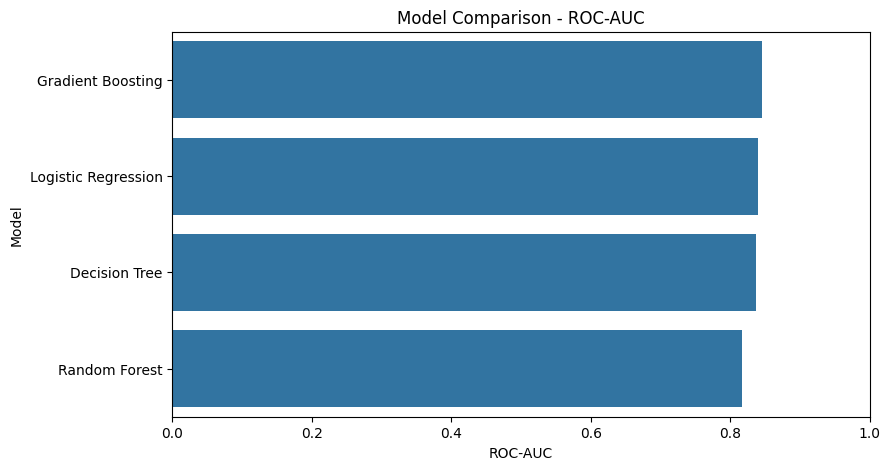

In [155]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results,
    x="ROC-AUC",
    y="Model"
)

plt.title("Model Comparison - ROC-AUC")
plt.xlabel("ROC-AUC")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

In [156]:
best_model_name = results.loc[
    results["ROC-AUC"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


In [157]:
model_dictionary = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

best_model = model_dictionary[best_model_name]

print("Best model selected successfully!")

Best model selected successfully!


In [158]:
import joblib

joblib.dump(
    best_model,
    "best_churn_model.pkl"
)

print("Best model saved successfully!")

Best model saved successfully!


In [159]:
best_predictions = best_model.predict(X_test)

best_probabilities = best_model.predict_proba(
    X_test
)[:, 1]

## 14. Churn Prediction

In [160]:
prediction_results = pd.DataFrame({
    "CustomerID": customer_ids.loc[X_test.index].values,
    "ActualChurn": y_test.values,
    "ChurnProbability": best_probabilities,
    "PredictedChurn": best_predictions
})

In [161]:
prediction_results.head(10)

,CustomerID,ActualChurn,ChurnProbability,PredictedChurn
0,4376-KFVRS,0,0.054748,0
1,2754-SDJRD,0,0.735990,1
2,9917-KWRBE,0,0.063914,0
3,0365-GXEZS,0,0.327757,0
4,9385-NXKDA,0,0.044349,0
5,4686-UXDML,0,0.562051,1
6,2227-JRSJX,0,0.431533,0
7,4830-FAXFM,0,0.114283,0
8,1830-IPXVJ,0,0.027650,0
9,4690-LLKUA,1,0.365617,0


In [162]:
best_predictions = best_model.predict(X_test)

best_probabilities = best_model.predict_proba(X_test)[:, 1]

In [163]:
print("Predictions:", best_predictions[:10])
print("Probabilities:", best_probabilities[:10])

Predictions: [0 1 0 0 0 1 0 0 0 0]
Probabilities: [0.05474826 0.73598976 0.06391421 0.32775738 0.04434866 0.56205063
 0.43153344 0.11428305 0.02765008 0.36561719]


In [164]:
prediction_results = pd.DataFrame({
    "CustomerID": customer_ids.loc[X_test.index].values,
    "ActualChurn": y_test.values,
    "ChurnProbability": best_probabilities,
    "PredictedChurn": best_predictions
})

In [165]:
prediction_results.head(10)

,CustomerID,ActualChurn,ChurnProbability,PredictedChurn
0,4376-KFVRS,0,0.054748,0
1,2754-SDJRD,0,0.735990,1
2,9917-KWRBE,0,0.063914,0
3,0365-GXEZS,0,0.327757,0
4,9385-NXKDA,0,0.044349,0
5,4686-UXDML,0,0.562051,1
6,2227-JRSJX,0,0.431533,0
7,4830-FAXFM,0,0.114283,0
8,1830-IPXVJ,0,0.027650,0
9,4690-LLKUA,1,0.365617,0


In [166]:
prediction_results["ChurnProbability"] = (
    prediction_results["ChurnProbability"] * 100
).round(2)

In [167]:
prediction_results.head(10)

,CustomerID,ActualChurn,ChurnProbability,PredictedChurn
0,4376-KFVRS,0,5.47,0
1,2754-SDJRD,0,73.60,1
2,9917-KWRBE,0,6.39,0
3,0365-GXEZS,0,32.78,0
4,9385-NXKDA,0,4.43,0
5,4686-UXDML,0,56.21,1
6,2227-JRSJX,0,43.15,0
7,4830-FAXFM,0,11.43,0
8,1830-IPXVJ,0,2.77,0
9,4690-LLKUA,1,36.56,0


## 15. Customer Risk Classification

In [169]:
def assign_risk(probability):

    if probability >= 70:
        return "High"

    elif probability >= 30:
        return "Medium"

    else:
        return "Low"

In [170]:
prediction_results["RiskLevel"] = (
    prediction_results["ChurnProbability"]
    .apply(assign_risk)
)

In [171]:
prediction_results.head(20)

,CustomerID,ActualChurn,ChurnProbability,PredictedChurn,RiskLevel
0,4376-KFVRS,0,5.47,0,Low
1,2754-SDJRD,0,73.60,1,High
2,9917-KWRBE,0,6.39,0,Low
3,0365-GXEZS,0,32.78,0,Medium
4,9385-NXKDA,0,4.43,0,Low
5,4686-UXDML,0,56.21,1,Medium
6,2227-JRSJX,0,43.15,0,Medium
7,4830-FAXFM,0,11.43,0,Low
8,1830-IPXVJ,0,2.77,0,Low
9,4690-LLKUA,1,36.56,0,Medium


In [172]:
prediction_results["RiskLevel"].value_counts()

,count
RiskLevel,
Low,893
Medium,420
High,96


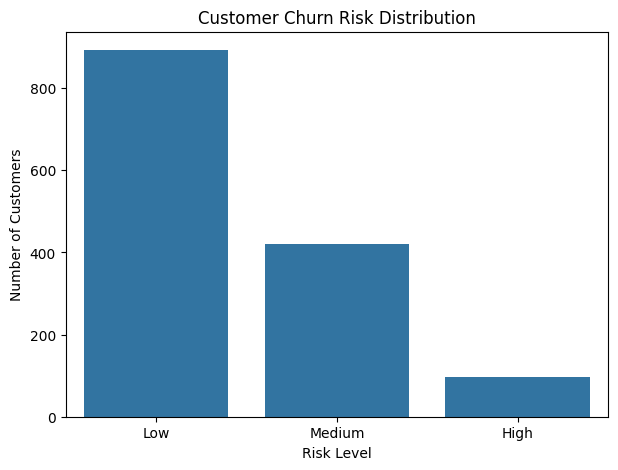

In [173]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=prediction_results,
    x="RiskLevel",
    order=["Low", "Medium", "High"]
)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.show()

In [174]:
high_risk_customers = prediction_results[
    prediction_results["RiskLevel"] == "High"
].sort_values(
    "ChurnProbability",
    ascending=False
)

In [175]:
high_risk_customers.head(20)

,CustomerID,ActualChurn,ChurnProbability,PredictedChurn,RiskLevel
1090,5178-LMXOP,1,86.89,1,High
1221,0295-PPHDO,1,86.67,1,High
1109,1069-XAIEM,1,85.57,1,High
618,9248-OJYKK,1,84.86,1,High
1259,2609-IAICY,1,84.62,1,High
647,6023-YEBUP,1,83.91,1,High
872,5167-ZFFMM,1,83.67,1,High
1164,8884-ADFVN,1,82.94,1,High
1175,6861-XWTWQ,1,82.94,1,High
38,4415-IJZTP,1,82.76,1,High


In [177]:
prediction_results = prediction_results.sort_values(
    "ChurnProbability",
    ascending=False
).reset_index(drop=True)

In [176]:
prediction_results.head(20)

,CustomerID,ActualChurn,ChurnProbability,PredictedChurn,RiskLevel
0,4376-KFVRS,0,5.47,0,Low
1,2754-SDJRD,0,73.60,1,High
2,9917-KWRBE,0,6.39,0,Low
3,0365-GXEZS,0,32.78,0,Medium
4,9385-NXKDA,0,4.43,0,Low
5,4686-UXDML,0,56.21,1,Medium
6,2227-JRSJX,0,43.15,0,Medium
7,4830-FAXFM,0,11.43,0,Low
8,1830-IPXVJ,0,2.77,0,Low
9,4690-LLKUA,1,36.56,0,Medium


In [178]:
prediction_results.to_csv(
    "customer_churn_predictions.csv",
    index=False
)

print("Prediction file saved successfully!")

Prediction file saved successfully!


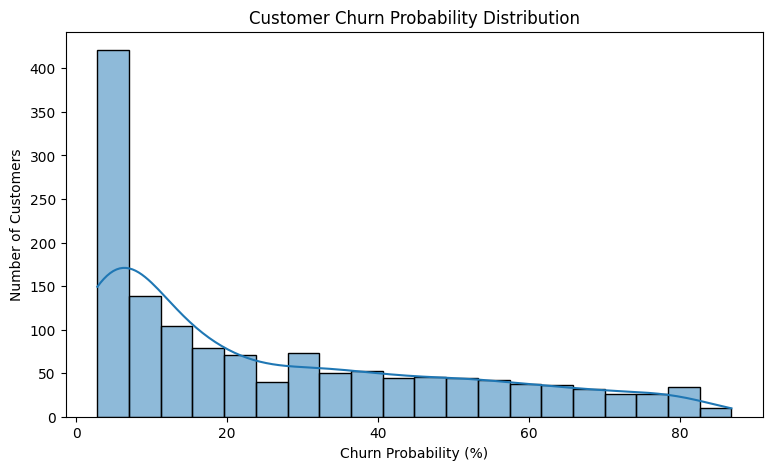

In [179]:
plt.figure(figsize=(9, 5))

sns.histplot(
    prediction_results["ChurnProbability"],
    bins=20,
    kde=True
)

plt.title("Customer Churn Probability Distribution")
plt.xlabel("Churn Probability (%)")
plt.ylabel("Number of Customers")

plt.show()

In [180]:
risk_summary = (
    prediction_results
    .groupby("RiskLevel")
    .agg(
        Customers=("CustomerID", "count"),
        AverageChurnProbability=("ChurnProbability", "mean")
    )
    .reindex(["Low", "Medium", "High"])
    .reset_index()
)

risk_summary["AverageChurnProbability"] = (
    risk_summary["AverageChurnProbability"].round(2)
)

risk_summary

,RiskLevel,Customers,AverageChurnProbability
0,Low,893,10.59
1,Medium,420,48.11
2,High,96,77.60


## 16. K-Means Customer Segmentation

In [181]:
# Use the Gradient Boosting model trained earlier
best_model = gradient_boosting_model

print("Best model:", best_model)

Best model: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   One

In [182]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Get churn probabilities from the Gradient Boosting model
y_prob = best_model.predict_proba(X_test)[:, 1]

threshold_results = []

# Test thresholds from 0.20 to 0.80
for threshold in np.arange(0.20, 0.81, 0.05):

    y_pred_threshold = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.20,0.715401,0.479326,0.836898,0.609542
1,0.25,0.745919,0.513699,0.802139,0.626305
2,0.30,0.771469,0.550388,0.759358,0.638202
3,0.35,0.783534,0.576837,0.692513,0.629405
4,0.40,0.787083,0.595855,0.614973,0.605263
5,0.45,0.801278,0.640719,0.572193,0.604520
6,0.50,0.804826,0.677419,0.505348,0.578867
7,0.55,0.804116,0.718750,0.430481,0.538462
8,0.60,0.792761,0.730337,0.347594,0.471014
9,0.65,0.782115,0.741007,0.275401,0.401559


In [183]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Best Threshold:", best_threshold)
print("Accuracy:", round(best_threshold_row["Accuracy"], 4))
print("Precision:", round(best_threshold_row["Precision"], 4))
print("Recall:", round(best_threshold_row["Recall"], 4))
print("F1 Score:", round(best_threshold_row["F1"], 4))

Best Threshold: 0.3
Accuracy: 0.7715
Precision: 0.5504
Recall: 0.7594
F1 Score: 0.6382


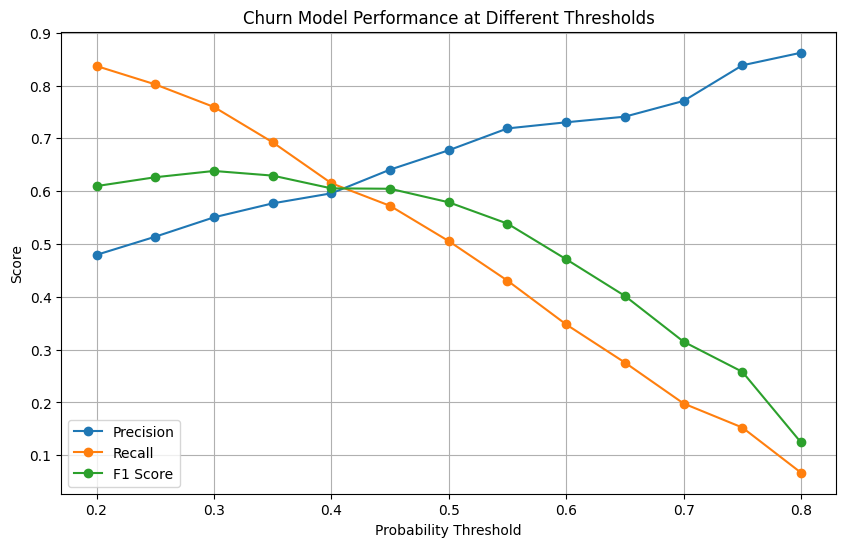

In [184]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Churn Model Performance at Different Thresholds")
plt.legend()
plt.grid(True)

plt.show()

In [185]:
# ==========================================
# STEP 20.1 — FINAL CHURN PREDICTIONS
# ==========================================

FINAL_THRESHOLD = 0.30

# Churn probabilities
final_probabilities = best_model.predict_proba(X_test)[:, 1]

# Apply optimized threshold
final_predictions = (
    final_probabilities >= FINAL_THRESHOLD
).astype(int)

print("Final Threshold:", FINAL_THRESHOLD)
print("Predicted Churn Customers:", final_predictions.sum())
print("Predicted Non-Churn Customers:", (final_predictions == 0).sum())

Final Threshold: 0.3
Predicted Churn Customers: 516
Predicted Non-Churn Customers: 893


In [186]:
# ==========================================
# STEP 20.2 — CUSTOMER CHURN PREDICTION TABLE
# ==========================================

final_predictions_df = pd.DataFrame({
    "CustomerID": customer_ids.loc[X_test.index].values,
    "ActualChurn": y_test.values,
    "ChurnProbability": final_probabilities,
    "PredictedChurn": final_predictions
})

# Convert probability to percentage
final_predictions_df["ChurnProbability"] = (
    final_predictions_df["ChurnProbability"] * 100
).round(2)

# Convert predictions to readable labels
final_predictions_df["PredictedChurnLabel"] = (
    final_predictions_df["PredictedChurn"]
    .map({
        0: "No",
        1: "Yes"
    })
)

final_predictions_df.head(10)

,CustomerID,ActualChurn,ChurnProbability,PredictedChurn,PredictedChurnLabel
0,4376-KFVRS,0,5.47,0,No
1,2754-SDJRD,0,73.60,1,Yes
2,9917-KWRBE,0,6.39,0,No
3,0365-GXEZS,0,32.78,1,Yes
4,9385-NXKDA,0,4.43,0,No
5,4686-UXDML,0,56.21,1,Yes
6,2227-JRSJX,0,43.15,1,Yes
7,4830-FAXFM,0,11.43,0,No
8,1830-IPXVJ,0,2.77,0,No
9,4690-LLKUA,1,36.56,1,Yes


In [187]:
# ==========================================
# STEP 20.3 — RISK LEVEL
# ==========================================

def assign_risk(probability):
    if probability >= 70:
        return "High"
    elif probability >= 30:
        return "Medium"
    else:
        return "Low"


final_predictions_df["RiskLevel"] = (
    final_predictions_df["ChurnProbability"]
    .apply(assign_risk)
)

final_predictions_df.head(10)

,CustomerID,ActualChurn,ChurnProbability,PredictedChurn,PredictedChurnLabel,RiskLevel
0,4376-KFVRS,0,5.47,0,No,Low
1,2754-SDJRD,0,73.60,1,Yes,High
2,9917-KWRBE,0,6.39,0,No,Low
3,0365-GXEZS,0,32.78,1,Yes,Medium
4,9385-NXKDA,0,4.43,0,No,Low
5,4686-UXDML,0,56.21,1,Yes,Medium
6,2227-JRSJX,0,43.15,1,Yes,Medium
7,4830-FAXFM,0,11.43,0,No,Low
8,1830-IPXVJ,0,2.77,0,No,Low
9,4690-LLKUA,1,36.56,1,Yes,Medium


In [188]:
# ==========================================
# STEP 20.4 — RISK DISTRIBUTION
# ==========================================

risk_summary = (
    final_predictions_df["RiskLevel"]
    .value_counts()
    .reindex(["High", "Medium", "Low"])
    .fillna(0)
    .astype(int)
)

print(risk_summary)

RiskLevel
High       96
Medium    420
Low       893
Name: count, dtype: int64


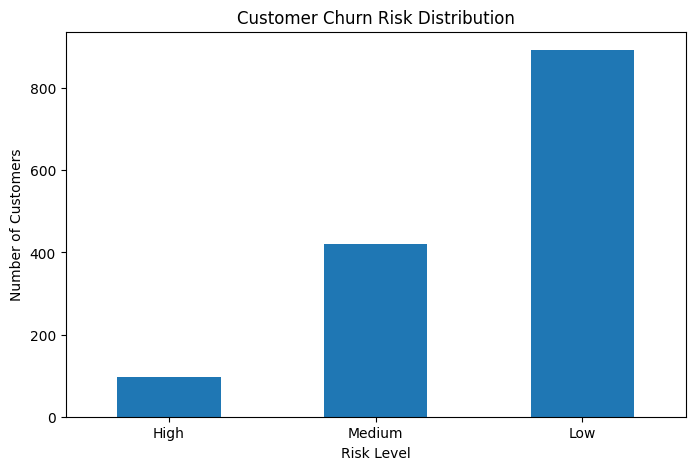

In [189]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

risk_summary.plot(kind="bar")

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

In [190]:
# ==========================================
# STEP 20.5 — HIGH RISK CUSTOMERS
# ==========================================

high_risk_customers = (
    final_predictions_df[
        final_predictions_df["RiskLevel"] == "High"
    ]
    .sort_values(
        by="ChurnProbability",
        ascending=False
    )
)

high_risk_customers.head(20)

,CustomerID,ActualChurn,ChurnProbability,PredictedChurn,PredictedChurnLabel,RiskLevel
1090,5178-LMXOP,1,86.89,1,Yes,High
1221,0295-PPHDO,1,86.67,1,Yes,High
1109,1069-XAIEM,1,85.57,1,Yes,High
618,9248-OJYKK,1,84.86,1,Yes,High
1259,2609-IAICY,1,84.62,1,Yes,High
647,6023-YEBUP,1,83.91,1,Yes,High
872,5167-ZFFMM,1,83.67,1,Yes,High
1164,8884-ADFVN,1,82.94,1,Yes,High
1175,6861-XWTWQ,1,82.94,1,Yes,High
38,4415-IJZTP,1,82.76,1,Yes,High


## 17. Churn + Segmentation Analysis

In [192]:
# ==========================================
# STEP 21.1 — PREPARE CUSTOMER SEGMENTATION
# ==========================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Ensure 'TotalCharges' is numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Define service columns for TotalServices
service_columns = [
    "PhoneService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# Create 'TotalServices' feature
df["TotalServices"] = (
    df[service_columns]
    .apply(lambda col: col.eq("Yes").astype(int))
    .sum(axis=1)
)

# Create 'AverageMonthlySpend' feature
df["AverageMonthlySpend"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

# Select customer behavior features
segmentation_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "TotalServices",
    "AverageMonthlySpend",
    "SeniorCitizen"
]

X_seg = df[segmentation_features].copy()

print("Segmentation dataset shape:", X_seg.shape)
print("\nFeatures used:")
print(segmentation_features)

X_seg.head()

Segmentation dataset shape: (7043, 6)

Features used:
['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'AverageMonthlySpend', 'SeniorCitizen']


,tenure,MonthlyCharges,TotalCharges,TotalServices,AverageMonthlySpend,SeniorCitizen
0,1,29.85,29.85,1,29.850000,0
1,34,56.95,1889.50,3,55.573529,0
2,2,53.85,108.15,3,54.075000,0
3,45,42.30,1840.75,3,40.905556,0
4,2,70.70,151.65,1,75.825000,0


In [196]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ==========================================
# STEP 21.2 — FEATURE SCALING AND IMPUTATION
# ==========================================

# Handle missing values in X_seg before scaling
imputer = SimpleImputer(strategy='mean') # Using mean imputation
X_seg_imputed = imputer.fit_transform(X_seg)

scaler = StandardScaler()

X_seg_scaled = scaler.fit_transform(X_seg_imputed) # Scale the imputed data

print("Scaled data shape:", X_seg_scaled.shape)
print("NaNs in scaled data:", np.isnan(X_seg_scaled).sum()) # Verify no NaNs

Scaled data shape: (7043, 6)
NaNs in scaled data: 0


In [197]:
# ==========================================
# STEP 22.1 — K-MEANS CLUSTERING
# ==========================================

from sklearn.cluster import KMeans

K = 4

kmeans_final = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_seg_scaled)

# Add cluster labels to original dataframe
df_segmented = df.copy()

df_segmented["Cluster"] = cluster_labels

print("K-Means clustering completed!")
print("Number of clusters:", K)

print("\nCustomers in each cluster:")
print(df_segmented["Cluster"].value_counts().sort_index())

K-Means clustering completed!
Number of clusters: 4

Customers in each cluster:
Cluster
0    1783
1    2179
2    2171
3     910
Name: count, dtype: int64


In [198]:
# ==========================================
# STEP 22.2 — SEGMENT PROFILE
# ==========================================

segment_profile = (
    df_segmented
    .groupby("Cluster")[segmentation_features]
    .mean()
    .round(2)
)

segment_profile

,tenure,MonthlyCharges,TotalCharges,TotalServices,AverageMonthlySpend,SeniorCitizen
Cluster,,,,,,
0,60.01,91.83,5500.57,5.12,91.89,0.09
1,27.22,26.59,701.95,1.13,26.54,0.04
2,16.80,74.28,1225.78,2.94,74.35,0.00
3,27.68,80.41,2272.83,3.02,80.25,1.00


In [199]:
# ==========================================
# STEP 22.3 — CHURN RATE BY SEGMENT
# ==========================================

segment_churn = (
    df_segmented
    .groupby("Cluster")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .reset_index(name="ChurnRate")
)

segment_churn

,Cluster,ChurnRate
0,0,13.12
1,1,14.46
2,2,40.86
3,3,47.58


In [200]:
# ==========================================
# STEP 22.4 — CUSTOMER COUNT
# ==========================================

segment_count = (
    df_segmented
    .groupby("Cluster")
    .size()
    .reset_index(name="CustomerCount")
)

segment_count

,Cluster,CustomerCount
0,0,1783
1,1,2179
2,2,2171
3,3,910


In [201]:
# ==========================================
# STEP 22.5 — COMPLETE SEGMENT PROFILE
# ==========================================

segment_summary = (
    segment_profile
    .reset_index()
    .merge(segment_churn, on="Cluster")
    .merge(segment_count, on="Cluster")
)

segment_summary

,Cluster,tenure,MonthlyCharges,TotalCharges,TotalServices,AverageMonthlySpend,SeniorCitizen,ChurnRate,CustomerCount
0,0,60.01,91.83,5500.57,5.12,91.89,0.09,13.12,1783
1,1,27.22,26.59,701.95,1.13,26.54,0.04,14.46,2179
2,2,16.80,74.28,1225.78,2.94,74.35,0.00,40.86,2171
3,3,27.68,80.41,2272.83,3.02,80.25,1.00,47.58,910


In [202]:
# ==========================================
# STEP 22.6 — HIGHEST CHURN SEGMENT
# ==========================================

highest_churn_segment = segment_summary.loc[
    segment_summary["ChurnRate"].idxmax()
]

print("Highest Churn Segment:")
print(highest_churn_segment)

Highest Churn Segment:
Cluster                   3.00
tenure                   27.68
MonthlyCharges           80.41
TotalCharges           2272.83
TotalServices             3.02
AverageMonthlySpend      80.25
SeniorCitizen             1.00
ChurnRate                47.58
CustomerCount           910.00
Name: 3, dtype: float64


In [203]:
# ==========================================
# STEP 22.7 — HIGHEST VALUE SEGMENT
# ==========================================

segment_summary["CustomerValueScore"] = (
    segment_summary["MonthlyCharges"] +
    segment_summary["TotalCharges"] / 10
)

highest_value_segment = segment_summary.loc[
    segment_summary["CustomerValueScore"].idxmax()
]

print("Highest Value Segment:")
print(highest_value_segment)

Highest Value Segment:
Cluster                   0.000
tenure                   60.010
MonthlyCharges           91.830
TotalCharges           5500.570
TotalServices             5.120
AverageMonthlySpend      91.890
SeniorCitizen             0.090
ChurnRate                13.120
CustomerCount          1783.000
CustomerValueScore      641.887
Name: 0, dtype: float64


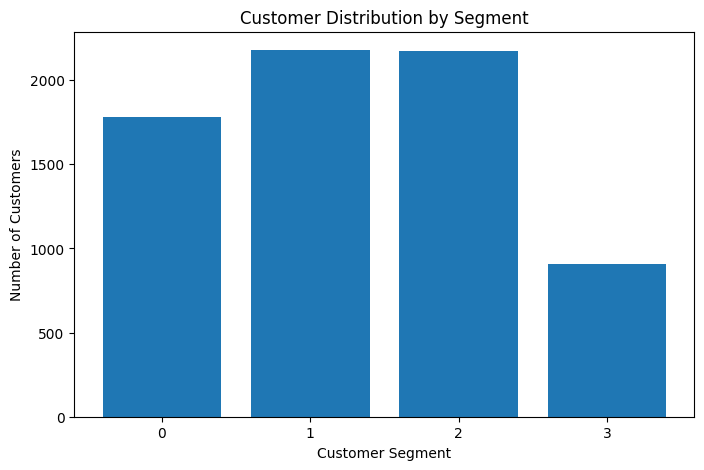

In [204]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    segment_summary["Cluster"].astype(str),
    segment_summary["CustomerCount"]
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Segment")

plt.show()

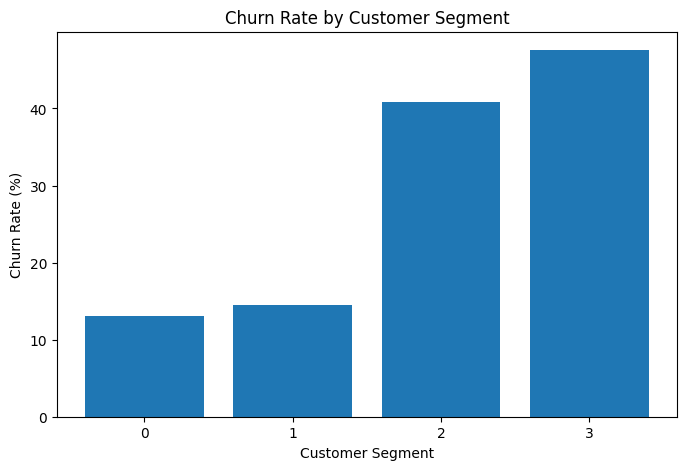

In [205]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_summary["Cluster"].astype(str),
    segment_summary["ChurnRate"]
)

plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Customer Segment")

plt.show()

In [206]:
# ==========================================
# STEP 22.9 — SEGMENT CHARACTERISTICS
# ==========================================

for cluster in sorted(df_segmented["Cluster"].unique()):

    cluster_data = df_segmented[
        df_segmented["Cluster"] == cluster
    ]

    print("=" * 60)
    print(f"CLUSTER {cluster}")
    print("=" * 60)

    print("Customers:", len(cluster_data))
    print("Average Tenure:",
          round(cluster_data["tenure"].mean(), 2))

    print("Average Monthly Charges:",
          round(cluster_data["MonthlyCharges"].mean(), 2))

    print("Average Total Charges:",
          round(cluster_data["TotalCharges"].mean(), 2))

    print("Average Total Services:",
          round(cluster_data["TotalServices"].mean(), 2))

    print("Churn Rate:",
          round(
              (cluster_data["Churn"] == "Yes").mean() * 100,
              2
          ),
          "%")

    print()

CLUSTER 0
Customers: 1783
Average Tenure: 60.01
Average Monthly Charges: 91.83
Average Total Charges: 5500.57
Average Total Services: 5.12
Churn Rate: 13.12 %

CLUSTER 1
Customers: 2179
Average Tenure: 27.22
Average Monthly Charges: 26.59
Average Total Charges: 701.95
Average Total Services: 1.13
Churn Rate: 14.46 %

CLUSTER 2
Customers: 2171
Average Tenure: 16.8
Average Monthly Charges: 74.28
Average Total Charges: 1225.78
Average Total Services: 2.94
Churn Rate: 40.86 %

CLUSTER 3
Customers: 910
Average Tenure: 27.68
Average Monthly Charges: 80.41
Average Total Charges: 2272.83
Average Total Services: 3.02
Churn Rate: 47.58 %



## 18. Export Results

In [207]:


# Use the same features that were used to train the model
X_all = df_ml.drop("Churn", axis=1)

# Predict churn probability for every customer
all_churn_probabilities = best_model.predict_proba(X_all)[:, 1]

# Apply optimized threshold
all_churn_predictions = (
    all_churn_probabilities >= FINAL_THRESHOLD
).astype(int)

print("Total Customers:", len(X_all))
print("Predicted Churn:", all_churn_predictions.sum())
print("Predicted No Churn:", (all_churn_predictions == 0).sum())

Total Customers: 7043
Predicted Churn: 2540
Predicted No Churn: 4503


In [209]:
# ==========================================
# STEP 21.2 — FINAL POWER BI DATASET
# ==========================================

powerbi_df = df.copy()

# Churn probability
powerbi_df["ChurnProbability"] = (
    all_churn_probabilities * 100
).round(2)

# Predicted churn
powerbi_df["PredictedChurn"] = all_churn_predictions

powerbi_df["PredictedChurnLabel"] = (
    powerbi_df["PredictedChurn"]
    .map({
        0: "No",
        1: "Yes"
    })
)

# Risk level
powerbi_df["RiskLevel"] = (
    powerbi_df["ChurnProbability"]
    .apply(assign_risk)
)

# Add K-Means customer segment
powerbi_df["Cluster"] = cluster_labels

import os

# Create the directory if it doesn't exist
output_dir = "customer_churn_outputs"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save
powerbi_df.to_csv(
    os.path.join(output_dir, "powerbi_customer_data.csv"),
    index=False
)

print("✅ Power BI dataset created!")
print("Rows:", powerbi_df.shape[0])
print("Columns:", powerbi_df.shape[1])

powerbi_df.head()

✅ Power BI dataset created!
Rows: 7043
Columns: 28


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,MonthlyCharges,TotalCharges,Churn,TotalServices,AverageMonthlySpend,ChurnProbability,PredictedChurn,PredictedChurnLabel,RiskLevel,Cluster
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,29.85,29.85,No,1,29.850000,64.96,1,Yes,Medium,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,56.95,1889.50,No,3,55.573529,5.47,0,No,Low,2
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,53.85,108.15,Yes,3,54.075000,29.51,0,No,Low,2
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,42.30,1840.75,No,3,40.905556,4.81,0,No,Low,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,70.70,151.65,Yes,1,75.825000,65.36,1,Yes,Medium,2


In [210]:
# ==========================================
# STEP 21.4 — POWER BI KPI SUMMARY
# ==========================================

total_customers = len(powerbi_df)

actual_churn = (
    powerbi_df["Churn"] == "Yes"
).sum()

predicted_churn = (
    powerbi_df["PredictedChurn"] == 1
).sum()

high_risk = (
    powerbi_df["RiskLevel"] == "High"
).sum()

medium_risk = (
    powerbi_df["RiskLevel"] == "Medium"
).sum()

low_risk = (
    powerbi_df["RiskLevel"] == "Low"
).sum()

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Actual Churn Customers",
        "Predicted Churn Customers",
        "High Risk Customers",
        "Medium Risk Customers",
        "Low Risk Customers"
    ],
    "Value": [
        total_customers,
        actual_churn,
        predicted_churn,
        high_risk,
        medium_risk,
        low_risk
    ]
})

kpi_summary

,Metric,Value
0,Total Customers,7043
1,Actual Churn Customers,1869
2,Predicted Churn Customers,2540
3,High Risk Customers,507
4,Medium Risk Customers,2033
5,Low Risk Customers,4503
